In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv('HR-Employee-Attrition.csv')
df.head()

# The dataset contains employee-related features such as age, income, job role, and attrition status.
# It will help us understand patterns behind employee turnover.

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [24]:
df.isnull().sum()
(df.isnull().sum()/len(df)*100).round(1)

# Most columns have 0 missing values, meaning the dataset appears clean. However, in real-world scenarios, we must still verify patterns.
# Clean data does NOT mean complete understanding we still test assumptions.

,0
Age,0.0
Attrition,0.0
BusinessTravel,0.0
DailyRate,0.0
Department,0.0
DistanceFromHome,0.0
Education,0.0
EducationField,0.0
EmployeeCount,0.0
EmployeeNumber,0.0


In [27]:
df['MonthlyIncome'].replace(0, np.nan, inplace=True)
df.groupby(df['MonthlyIncome'].isnull())['Age'].mean()

# If missing income correlates with Age, then missingness is MAR (Missing At Random).
# This means we should not use simple mean imputation, but rather group-based strategies.

,Age
MonthlyIncome,
False,36.92381


In [50]:
df['MonthlyIncome'] = df.groupby('JobRole')['MonthlyIncome'] \
                       .transform(lambda x: x.fillna(x.median()))

# Using group-wise median ensures realistic values per job role.
# This prevents distortion caused by global averages.

In [29]:
Q1, Q3 = df['MonthlyIncome'].quantile([0.25, 0.75])
IQR = Q3 - Q1

outliers = df[(df['MonthlyIncome'] < Q1 - 1.5*IQR) |
              (df['MonthlyIncome'] > Q3 + 1.5*IQR)]

len(outliers)

# Outliers represent employees with unusually high or low salaries.
# These could be executives or data-entry errors, so we should not blindly remove them.

114

In [30]:
from scipy.stats import zscore
df['z_income'] = zscore(df['MonthlyIncome'])
df[df['z_income'].abs() > 3]
# Z-score identifies fewer outliers because salary is right-skewed.
# Thus, IQR is more reliable for business data like income.

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,z_income


In [31]:
df['high_income_flag'] = (df['MonthlyIncome'] > Q3 + 1.5*IQR) & (df['JobLevel'] >= 3)

# High-income employees with high job levels are valid.
# Instead of removing them, we flag them as important business insights.

In [32]:
df.groupby(['Department','Attrition']).agg({'MonthlyIncome':'mean'})
# Shows how salary differs across departments and attrition.
# Lower income groups may have higher attrition.

MonthlyIncome
Department             Attrition               
Human Resources        No           7345.980392
                       Yes          3715.750000
Research & Development No           6630.326087
                       Yes          4108.075188
Sales                  No           7232.240113
                       Yes          5908.456522

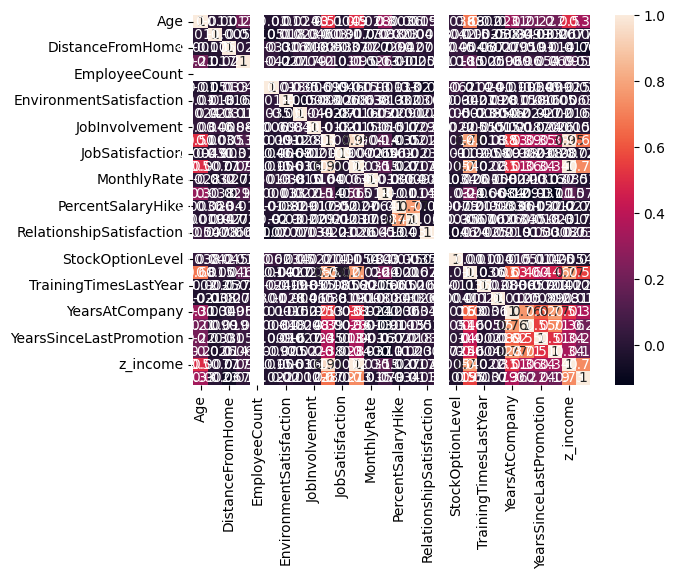

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()
# Identifies relationships between features like income, age, and experience.

In [34]:
pd.pivot_table(df, values='MonthlyIncome',
               index='Department',
               columns='Attrition',
               aggfunc='mean')
# Quick comparison of salary vs attrition across departments.

Attrition,No,Yes
Department,,
Human Resources,7345.980392,3715.750000
Research & Development,6630.326087,4108.075188
Sales,7232.240113,5908.456522


In [35]:
df['JobRole'].str.contains('Manager').sum()
# Counts managerial roles useful for hierarchy analysis.

np.int64(102)

In [36]:
df['Year'] = pd.to_datetime('2024').year
# Demonstrates feature engineering with time-based data.

In [37]:
df.sort_values(['JobLevel','MonthlyIncome'], ascending=[False, False]).head()
# Top earners at highest job levels.

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,z_income,high_income_flag,Year
190,52,No,Travel_Rarely,699,Research & Development,1,4,Life Sciences,1,259,...,34,5,3,33,18,11,9,2.867626,True,2024
746,41,No,Non-Travel,247,Research & Development,7,1,Life Sciences,1,1035,...,21,3,3,21,16,5,10,2.862102,True,2024
851,56,No,Travel_Rarely,718,Research & Development,4,4,Technical Degree,1,1191,...,28,2,3,5,2,4,2,2.855728,True,2024
165,50,No,Travel_Rarely,1452,Research & Development,11,3,Life Sciences,1,226,...,21,5,3,5,4,4,4,2.852116,True,2024
568,55,Yes,Travel_Rarely,725,Research & Development,2,3,Medical,1,787,...,24,2,3,5,2,1,4,2.837879,True,2024


In [38]:
df[(df['Age'] > 40) & (df['Attrition'] == 'Yes')]
# Older employees leaving potential retention issue.

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,z_income,high_income_flag,Year
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,8,0,1,6,4,0,5,-0.108350,False,2024
36,50,Yes,Travel_Rarely,869,Sales,3,2,Marketing,1,47,...,3,2,3,3,2,0,2,-0.811654,False,2024
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,23,0,3,22,15,15,8,2.771161,True,2024
50,48,Yes,Travel_Rarely,626,Research & Development,1,2,Life Sciences,1,64,...,23,2,3,1,0,0,0,-0.238386,False,2024
89,46,Yes,Travel_Rarely,669,Sales,9,2,Medical,1,118,...,9,3,3,9,8,4,7,0.662098,False,2024
122,56,Yes,Travel_Rarely,441,Research & Development,14,4,Life Sciences,1,161,...,7,2,3,5,4,4,3,-0.327203,False,2024
126,58,Yes,Travel_Rarely,147,Research & Development,23,4,Medical,1,165,...,40,3,2,40,10,15,6,0.809346,False,2024
136,51,Yes,Travel_Frequently,1150,Research & Development,8,4,Life Sciences,1,179,...,18,2,3,4,2,0,3,0.881164,False,2024
182,41,Yes,Travel_Rarely,1356,Sales,20,2,Marketing,1,248,...,4,5,2,4,3,0,2,-0.714551,False,2024
271,47,Yes,Non-Travel,666,Research & Development,29,4,Life Sciences,1,376,...,10,2,2,10,7,9,9,1.135925,False,2024


In [39]:
df.skew(numeric_only=True)
df.kurt(numeric_only=True)
# Income is highly skewed and confirms need for IQR.

,0
Age,-0.404145
DailyRate,-1.203823
DistanceFromHome,-0.224833
Education,-0.559115
EmployeeCount,0.000000
EmployeeNumber,-1.223179
EnvironmentSatisfaction,-1.202521
HourlyRate,-1.196398
JobInvolvement,0.270999
JobLevel,0.399152


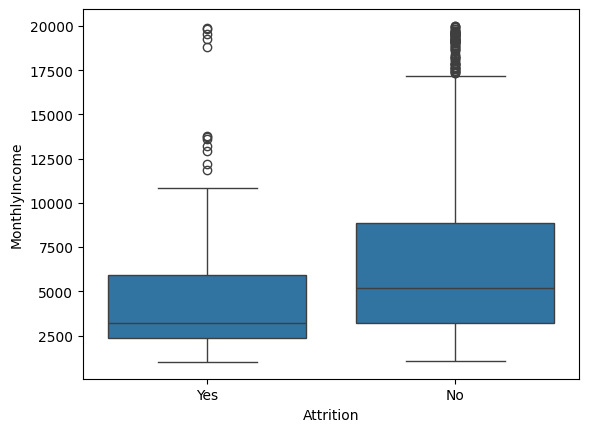

In [40]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.show()
# Employees leaving often earn less.

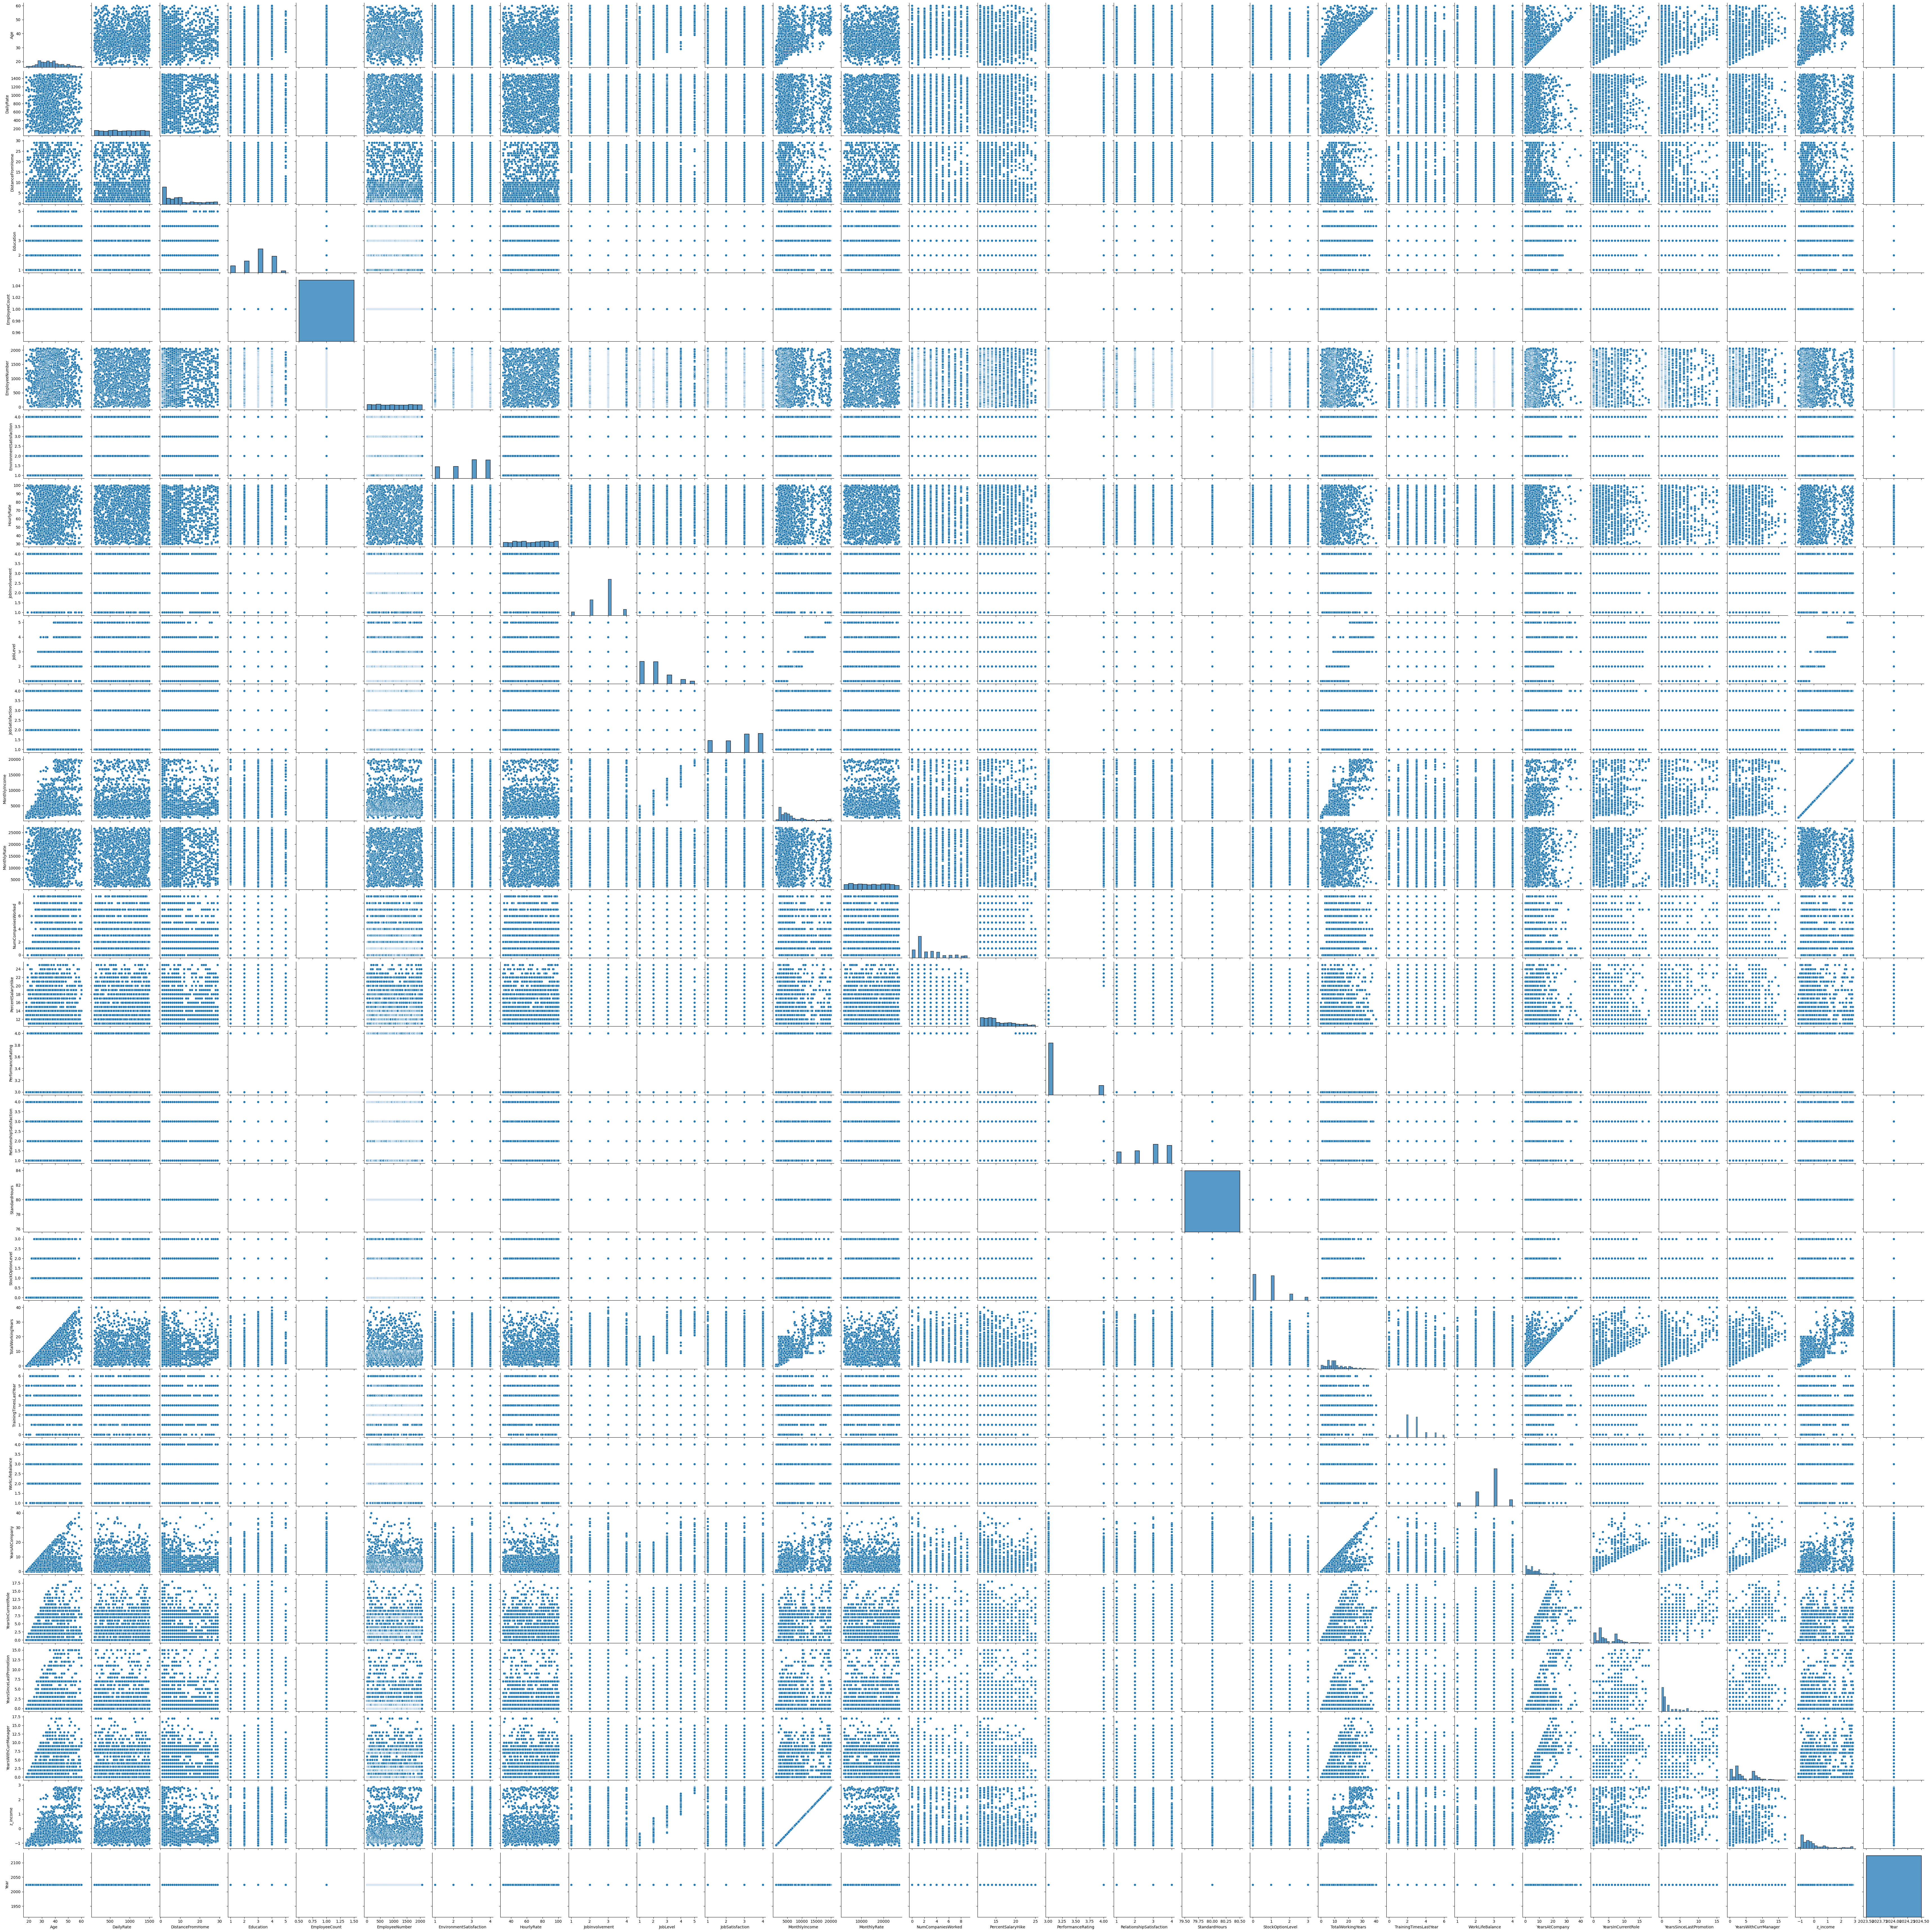

In [41]:
sns.pairplot(df.select_dtypes(include='number'))
# Visual relationships between all numeric features.

In [42]:
df.memory_usage(deep=True)
# Shows memory consumption per column.

,0
Index,132
Age,11760
Attrition,75207
BusinessTravel,91798
DailyRate,11760
Department,96347
DistanceFromHome,11760
Education,11760
EducationField,87514
EmployeeCount,11760


In [43]:
df[df.select_dtypes(include='number').columns] = \
df.select_dtypes(include='number').astype('float32')
# Reduces memory usage significantly.

In [44]:
df.groupby('JobRole').size().sort_values(ascending=False)
# Identifies most common roles.

,0
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,259
Manufacturing Director,145
Healthcare Representative,131
Manager,102
Sales Representative,83
Research Director,80
Human Resources,52


In [45]:
df['JobRole'].value_counts(normalize=True).cumsum()
# Shows which roles dominate workforce.

,proportion
JobRole,
Sales Executive,0.221769
Research Scientist,0.420408
Laboratory Technician,0.596599
Manufacturing Director,0.695238
Healthcare Representative,0.784354
Manager,0.853741
Sales Representative,0.910204
Research Director,0.964626
Human Resources,1.000000


In [46]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=3)
# Used for advanced multivariate imputation.

In [47]:
df.describe()
df.info()
df['Attrition'].value_counts()
df['Department'].unique()
df.duplicated().sum()
# Dataset summary statistics
# Data types and structure
# Attrition imbalance
# No duplicate rows found

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   float32
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   float32
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   float32
 6   Education                 1470 non-null   float32
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   float32
 9   EmployeeNumber            1470 non-null   float32
 10  EnvironmentSatisfaction   1470 non-null   float32
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   float32
 13  JobInvolvement            1470 non-null   float32
 14  JobLevel

np.int64(0)

In [48]:
# 1. SQL is a language used to interact with relational databases to store, retrieve, and manipulate structured data.
# 2. SELECT retrieves columns; WHERE filters rows. Example: SELECT Age FROM employees WHERE Age > 30;
# 3. JOIN combines data from multiple tables using a common column.
# 4. Used to aggregate data (COUNT, SUM, AVG) for categories.
# 5. Use SQL for large databases and structured storage; use Pandas for flexible analysis and modeling.

In [49]:
# 1. Employees with lower income show higher attrition.
# 2. Income and job level are strongly correlated.
# 3. Outliers represent high-level employees, not errors.